### 📦 Install Dependencies
This cell installs required libraries.

In [ ]:
!pip install openai networkx matplotlib

### 📚 Import Libraries
Load all required Python modules.

In [ ]:
import openai
import networkx as nx
import matplotlib.pyplot as plt
import ast
import numpy as np

### 🔑 Add OpenAI API Key
Replace with your own key.

In [ ]:
from openai import OpenAI
client = OpenAI(api_key = "YOUR_API_KEY")

### ✏️ Define Input Text
Sentence to extract relations from.

In [ ]:
text = "Customer 2345 reported: My laptop overheats after the latest update. Support team note: The issue was respolved after applying Patch 1.2"

### 🧠 Create LLM Prompt
Prompt for extracting triplets.

In [ ]:
prompt = f"""
Extract entities and relationships from the following text and output them
AS A PYTHON LIST OF TRIPLETS.

Your output MUST follow this exact format:
[
  ("Entity1", "relationship_label", "Entity2"),
  ("EntityA", "relationship_label", "EntityB")
]

======================================================
ONTOLOGY (USE THIS STRUCTURE EXACTLY)
======================================================

ENTITY TYPES:
- Customer: A person or account reporting an issue.
- Issue: A problem, malfunction, or negative experience.
- Product: A device, service, or component affected by the issue.
- Cause: A root cause, update, action, or event that triggers the issue.
- Resolution: A fix, patch, workaround, or step that resolves the issue.

RELATIONSHIP TYPES (snake_case only):
- reports: Customer → Issue
- affects: Issue → Product
- caused_by: Issue → Cause
- resolved_by: Issue → Resolution

SCHEMA RULES:
1. All entity names must be **descriptive and capitalized**
   (e.g., Customer 4759, Overheating Issue, Latest Update, Patch 1.2).
2. All relationships must use the ontology labels above.
3. If the text implies a support ticket, infer:
     Customer → reports → Issue
4. Extract **all meaningful triplets**, not just one.
5. Do NOT include explanations — output ONLY the Python list.

======================================================

Text:
{text}
"""


### 🚀 Run the LLM
Send the extraction request to the model.

In [ ]:


response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
    temperature=0
)

raw_output = response.choices[0].message.content
print("Raw LLM Output:", raw_output)


Raw LLM Output: [
  ("Customer 2345", "reports", "Overheating Issue"),
  ("Overheating Issue", "affects", "Laptop"),
  ("Overheating Issue", "caused_by", "Latest Update"),
  ("Overheating Issue", "resolved_by", "Patch 1.2")
]


### 📦 Parse Extracted Triplets
Convert model output to Python tuples.

In [ ]:
try:
    triplets = ast.literal_eval(raw_output)
except:
    triplets = []
    for line in raw_output.split("\n"):
        if "(" in line and ")" in line:
            try:
                triplets.append(ast.literal_eval(line.strip()))
            except:
                pass
print("Parsed Triplets:", triplets)

Parsed Triplets: [('Customer 2345', 'reports', 'Overheating Issue'), ('Overheating Issue', 'affects', 'Laptop'), ('Overheating Issue', 'caused_by', 'Latest Update'), ('Overheating Issue', 'resolved_by', 'Patch 1.2')]


### 🕸️ Build the Graph
Create nodes and edges from triplets.

In [ ]:
G = nx.DiGraph()
for subj, rel, obj in triplets:
    G.add_node(subj)
    G.add_node(obj)
    G.add_edge(subj, obj, label=rel)

### 🎨 Visualize the Mini Knowledge Graph
Render the extracted graph.

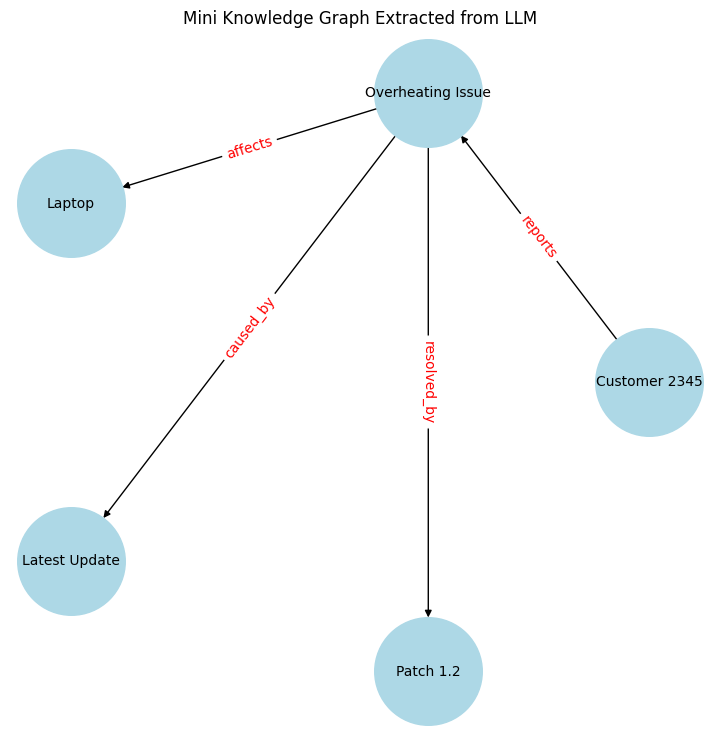

In [ ]:
plt.figure(figsize=(7, 7))
pos = nx.circular_layout(G)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=6000,
    font_size=10,
)

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red")

plt.title("Mini Knowledge Graph Extracted from LLM")
plt.show()
